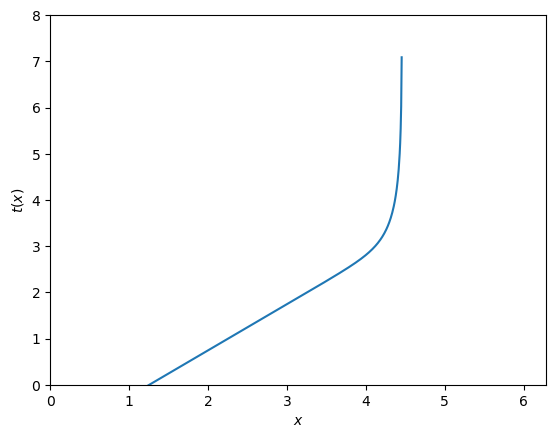

In [8]:
import numpy as np
import matplotlib.pyplot as plt

l = 2*np.pi
beta = lambda x: -0.6 * np.tanh(3*(x-2/3*l)) - 0.6

N = 1000
x0 = 0.2*l
x = np.linspace(0, l, N)
dx = x[1] - x[0]

f = 1/(1 + beta(x))        
t = np.zeros_like(x)
t[1:] = np.cumsum(0.5*(f[1:]+f[:-1])*dx)
t -= t[np.argmin(np.abs(x-x0))]

g = 1 + beta(x)
mask = g > 0 

np.savetxt(
    "geodesic/lr_p.csv",
    np.column_stack((x[mask], t[mask])),
    delimiter=",",
    header="x,t",
    comments=""
)

plt.plot(x[mask], t[mask])
plt.xlim(0,l)
plt.ylim(0, 8)
plt.xlabel(r"$x$")
plt.ylabel(r"$t(x)$")
plt.show()